In [1]:
#does not work not sure if it is worth trying to fix

In [1]:
import os
import math
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
from tqdm.notebook import tqdm
import numpy as np

from torch.utils.data import DataLoader, random_split
from torchvision.utils import save_image
from torchvision.io import read_image
from torchvision.transforms import Resize
from torchvision.transforms import Compose, ToTensor, Lambda, Pad
import torch.optim as optim
from PIL import Image
nn = torch.nn
F = nn.functional



import random



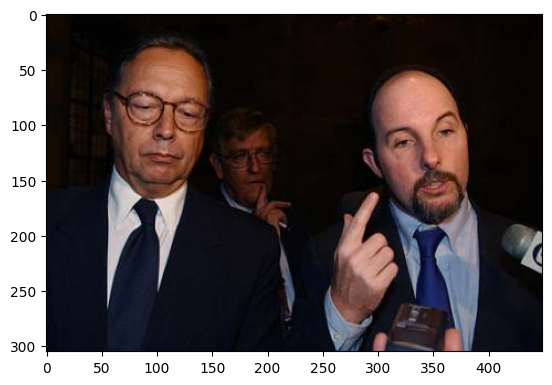

2548
2548
2548
Number of samples in the dataset:  2548


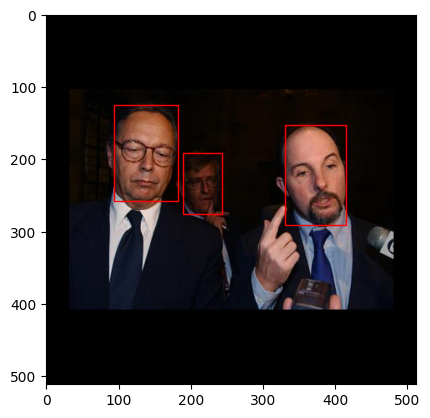

In [2]:
%run faceDetection.ipynb

In [3]:
def check_if_face(x, y, size, x_bbox, y_bbox, w_bbox, h_bbox, num_faces, threashold):
    
    for i in range(num_faces):
        x_intersect = max(x, x_bbox[i])
        y_intersect = max(y, y_bbox[i])
        w_intersect = min(x + size[0], x_bbox[i] + w_bbox[i]) - x_intersect
        h_intersect = min(y + size[1], y_bbox[i] + h_bbox[i]) - y_intersect

        if w_intersect > 0 or h_intersect > 0:
            area_intersect = w_intersect * h_intersect
            if (area_intersect/(size[0] * size[1]) >= threashold):
                return True
    return False
            
        

In [4]:
def create_patches(img, bbox, num_faces, size = (100, 100), val = False, step_size = 25):
    
    width = 512  # Get the width of the image (dimension at index 1)
    height = 512
    
    patches = []
    pos_patches = []
    neg_patches = []
    labels = []
    xs = []
    ys = []
    
    if val:
        step = step_size
        x = 0
        y = 0
    else:
        step = 100
        x = torch.randint(1, 11, (1,)).item()
        y = torch.randint(1, 11, (1,)).item()
    threashold = 0.6
    pos = 0
    neg = 0
    #read bboxes and their
    x_bbox = [0] * num_faces[0]
    y_bbox = [0] * num_faces[0]
    w_bbox = [0] * num_faces[0]
    h_bbox = [0] * num_faces[0]
    for i in range(num_faces[0]):
        x_bbox[i], y_bbox[i], w_bbox[i], h_bbox[i], _ = bbox[i, :]
        # FOR VAL/TRAIN
    if val:
        while(y + size[1] < height):
            while(x + size[0] < width):
                patch = img[y:y + size[1], x:x + size[0], :] #create patch
                patches.append(patch) 
                xs.append(x)
                ys.append(y)
                if check_if_face(x, y, size, x_bbox, y_bbox, w_bbox, h_bbox, num_faces, threashold):
                    labels.append(1) #one if it is a face patch 0 otherwise
                else:
                    labels.append(0)
                    
                x += step
            y += step
            x = 0
        return patches, labels, xs, ys
    else:
        while(y + size[1] < height):
            while(x + size[0] < width):
                patch = img[y:y + size[1], x:x + size[0], :] #create patch
                #patches.append(patch) 
                if check_if_face(x, y, size, x_bbox, y_bbox, w_bbox, h_bbox, num_faces, threashold):
                    #labels.append(1) #one if it is a face patch 0 otherwise
                    pos_patches.append(patch)
                    pos += 1
                else:
                    #labels.append(0)
                    neg_patches.append(patch)
                    neg += 1
                x += step
            y += step
            x = 0
        #patches = pos_patches + neg_patches
        #labels = [1] *len(pos_patches) + [0] * len(neg_patches)
    
    
        random.shuffle(neg_patches)
        if pos < neg:
            neg_patches = neg_patches[:pos]
        patches = pos_patches + neg_patches
        labels = [1] *len(pos_patches) + [0] * len(neg_patches)
        return patches, labels
    """
        combined = list(zip(patches, labels))

        # Shuffle the combined list
        random.shuffle(combined)
        
        # Separate the shuffled pairs back into two lists
        patches, labels = zip(*combined)
    
    """
    #patches = [torch.tensor(patch) for patch in patches]
    #labels = [torch.tensor(label) for label in labels]
    """
    while(y + size[1] < height):
        while(x + size[0] < width):
            patch = img[y:y + size[1], x:x + size[0], :] #create patch
            patches.append(patch) 
            if check_if_face(x, y, size, x_bbox, y_bbox, w_bbox, h_bbox, num_faces, threashold):
                labels.append(1) #one if it is a face patch 0 otherwise
            else:
                labels.append(0)
            x += step
        y += step
    x = 0

    #remove some of the negatives randomly

    while(pos < neg):
        r = torch.rand(1).item() * (tot - 1)
        r = int(r)
        if (labels[r] == 0):
            labels = labels[labels != r]
            patches = patches[patches != r]
            tot = tot - 1
            neg = neg - 1
    """
    
    
    
    

In [5]:
"""
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

batch_size = 64

#model = model.to(device)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
#classification_loss = nn.CrossEntropyLoss()
#box_loss = nn.MSELoss()
#num_patches = 10

epoch = 0
#model.train()
lbar = tqdm(train_loader)
lbar.set_description(f"Epoch {epoch}")
for batch_idx, (samples_batch, labels_batch, num_faces) in enumerate(lbar):
    #print(labels_batch.shape)
    for i in range(labels_batch.shape[0]):
        patches, labels = create_patches(samples_batch[i],labels_batch[i], num_faces[i])
    #plt.imshow(patches[10])
    #print(labels[10])
print("klar")

"""

'\ndevice = torch.device("cuda" if torch.cuda.is_available() else "cpu")\n\nbatch_size = 64\n\n#model = model.to(device)\ntrain_size = int(0.8 * len(dataset))\nval_size = len(dataset) - train_size\n\ntrain_dataset, val_dataset = random_split(dataset, [train_size, val_size])\ntrain_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False, num_workers=4)\nval_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)\n#classification_loss = nn.CrossEntropyLoss()\n#box_loss = nn.MSELoss()\n#num_patches = 10\n\nepoch = 0\n#model.train()\nlbar = tqdm(train_loader)\nlbar.set_description(f"Epoch {epoch}")\nfor batch_idx, (samples_batch, labels_batch, num_faces) in enumerate(lbar):\n    #print(labels_batch.shape)\n    for i in range(labels_batch.shape[0]):\n        patches, labels = create_patches(samples_batch[i],labels_batch[i], num_faces[i])\n    #plt.imshow(patches[10])\n    #print(labels[10])\nprint("klar")\n\n'

In [6]:
"""
sample, label, num_faces = train_dataset[5]

patches, labels = create_patches(sample,label, num_faces)
i = 25
print(patches[0].permute(2,1,0))
plt.imshow(patches[i])
print(labels[i])
#plt.imshow(sample)
print(num_faces)
"""

'\nsample, label, num_faces = train_dataset[5]\n\npatches, labels = create_patches(sample,label, num_faces)\ni = 25\nprint(patches[0].permute(2,1,0))\nplt.imshow(patches[i])\nprint(labels[i])\n#plt.imshow(sample)\nprint(num_faces)\n'

In [7]:
"""
from facenet_pytorch import MTCNN
mtcnn = MTCNN()
"""

'\nfrom facenet_pytorch import MTCNN\nmtcnn = MTCNN()\n'

In [8]:
import torchvision.models as models


#This code will freeze all layers in ResNet50 except for the last two layers (avgpool and fc). 
#The last layer fc is the fully connected layer which you might want to fine-tune for your specific task.

In [9]:
class Simple_CNN(nn.Module):
    def __init__(self):
        super(Simple_CNN, self).__init__()
        
        base_model = models.resnet50(pretrained=True)
        for name, param in base_model.named_children():
            if name not in ['avgpool', 'fc']:
                for layer in param.parameters():
                    layer.requires_grad = False
                    
        self.channels = [3, 32, 64, 128, 256, 512, 51200, 2]
        #self.mtcnn = MTCNN()
        self.resnet = base_model
        self.down_new = nn.Sequential(
            nn.Linear(1000, 2),
            nn.Softmax(dim=1)
        )
        self.down = nn.Sequential(
            nn.Conv2d(self.channels[0], self.channels[1], kernel_size=3),
            nn.BatchNorm2d(self.channels[1]),
            nn.ReLU(),
            nn.Conv2d(self.channels[1], self.channels[2], kernel_size=3),
            #nn.BatchNorm2d(self.channels[2]),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(self.channels[2], self.channels[3], kernel_size=3),
            nn.BatchNorm2d(self.channels[3]),
            nn.ReLU(),
            nn.Conv2d(self.channels[3], self.channels[4], kernel_size=3),
            #nn.BatchNorm2d(self.channels[4]),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(self.channels[4], self.channels[5], kernel_size=3),
            nn.BatchNorm2d(self.channels[5]),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Flatten(),
            nn.Linear(self.channels[6], self.channels[7]),
            nn.Softmax(dim=1)
        )


    def forward(self, x):
        x = self.resnet(x)
        #print(x.shape)
        x = self.down_new(x)
        #print(x.shape)
        return x
#p = torch.Tensor(patches)
#model = Simple_CNN()
#patches = patches.float()
#print(patches[28].permute(2,1,0).unsqueeze(0).shape)
#x = model(patches[28].permute(2,1,0).unsqueeze(0).float())



In [10]:
"""
def custom_loss(predictions, targets, weight_false_negatives):
    # Calculate binary cross entropy loss
    bce_loss = F.binary_cross_entropy(predictions, targets, reduction='none')

    # Calculate false negatives
    false_negatives = (targets[1] == 1) & (predictions[1] < 0.5)

    # Apply higher weight to false negatives
    weighted_loss = torch.where(false_negatives, weight_false_negatives * bce_loss, bce_loss)

    # Calculate mean loss
    loss = torch.mean(weighted_loss)

    return loss
"""

"\ndef custom_loss(predictions, targets, weight_false_negatives):\n    # Calculate binary cross entropy loss\n    bce_loss = F.binary_cross_entropy(predictions, targets, reduction='none')\n\n    # Calculate false negatives\n    false_negatives = (targets[1] == 1) & (predictions[1] < 0.5)\n\n    # Apply higher weight to false negatives\n    weighted_loss = torch.where(false_negatives, weight_false_negatives * bce_loss, bce_loss)\n\n    # Calculate mean loss\n    loss = torch.mean(weighted_loss)\n\n    return loss\n"

In [11]:
batch_size = 16  # Set your desired batch size
shuffle = True   # Set whether you want to shuffle the data
num_workers = 4  # Set the number of processes to load data
learning_rate = 0.005
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = Simple_CNN().to(device)
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

train_size = int(0.8 * len(dataset))
print(len(dataset))
#print(train_size)
val_size = len(dataset) - train_size
#print(val_size)
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=shuffle, num_workers=num_workers)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
num_epochs = 11
weight_false_negatives = 1
#mse_loss = nn.MSELoss()
#cross_loss = nn.CrossEntropyLoss()

#test of dataloader
#for batch_idx, (samples_batch, labels_batch) in enumerate(dataloader):    
 #   # Process each batch
  #  print("Batch Index:", batch_idx)
   # print("Samples shape:", samples_batch.shape)
    #print("Labels shape:", labels_batch.shape)
to_pil = torchvision.transforms.ToPILImage()

for epoch in range(num_epochs):
    model.train()
    lbar = tqdm(dataloader)
    lbar.set_description(f"Epoch {epoch}")
    for batch_idx, (samples_batch, labels_batch, num_faces) in enumerate(lbar):
        samples_batch, labels_batch, num_faces = samples_batch.to(device), labels_batch.to(device), num_faces.to(device)
        # Forward pass
        #samples_batch = samples_batch.permute(0,3,1,2).float()
        #loss = 0
        """
        print(samples_batch.shape)
        tensor_list = [samples_batch[b].to(device) for b in range(samples_batch.shape[0])]
        pil_list =[to_pil(samples_batch[b].to('cpu')) for b in range(samples_batch.shape[0])]
        print(len(tensor_list))
    
        print(tensor_list[0].shape)
        #print(len(pil_list))
        #print(pil_list[0])
        outputs = model(pil_list)
        """
        
        for i in range(labels_batch.shape[0]):
            patches, labels = create_patches(samples_batch[i],labels_batch[i], num_faces[i], val = False)
            #print(patches[0].shape)
            if (len(patches) > 0):
                patches = torch.stack(patches, dim=0).to(device)
                labels = torch.tensor(labels).to(device)
                outputs = model(patches.permute(0,3,1,2).float())
                #labels = F.one_hot(labels.float(), 2)
                labels = torch.stack([1 - labels, labels], dim=1).float()
                loss = F.cross_entropy(outputs, labels)
                #loss += custom_loss(outputs, labels, weight_false_negatives)
                
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

    lbar.close()
        # Validation phase
    model.eval()  # Set model to evaluation mode
    val_losses = []
    correct = 0
    positives = 0
    negatives = 0
    correct_positives = 0
    correct_negatives = 0
    total = 0
    with torch.no_grad():
        if (epoch % 5 == 0):
            for val_samples_batch, val_labels_batch, val_num_faces in val_dataloader:
                val_samples_batch, val_labels_batch, val_num_faces = val_samples_batch.to(device), val_labels_batch.to(device), val_num_faces.to(device)
                val_samples_batch = val_samples_batch.float()
                for i in range(val_labels_batch.shape[0]):
                    patches, labels, _, _ = create_patches(val_samples_batch[i],val_labels_batch[i], val_num_faces[i], val = True)
                    patches = torch.stack(patches, dim=0).to(device)
                    labels = torch.tensor(labels).to(device)
                    outputs = torch.argmax(model(patches.permute(0,3,1,2).float()), dim = 1)
                    correct += torch.sum(outputs == labels)
                    correct_positives += torch.sum(torch.eq(outputs, labels) & torch.eq(labels, 1))
                    correct_negatives += torch.sum(torch.eq(outputs, labels) & torch.eq(labels, 0))
                    
                    
                    positives += torch.sum(labels == 1)
                    negatives += torch.sum(labels==0)
                    total += len(labels)
                    #print("Sum of outputs: ", sum(outputs), " Sum of labels: ", sum(labels))

            print(f'Epoch [{epoch + 1}/{num_epochs}], Training Loss: {loss.item():.4f}, Validation Accuracy: {correct/total:.4f}')
            print(f'Accuracy for possitives: {correct_positives/positives}, Accuracy for negatives: {correct_negatives/negatives}')
    #print(total)
    #print(correct)

    #print("accuracy: ", loss/)


/home/johan/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/johan/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


2548


  0%|          | 0/128 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [18]:
torch.save(model, 'facefinder.pth')

In [12]:
model = torch.load('facefinder.pth')

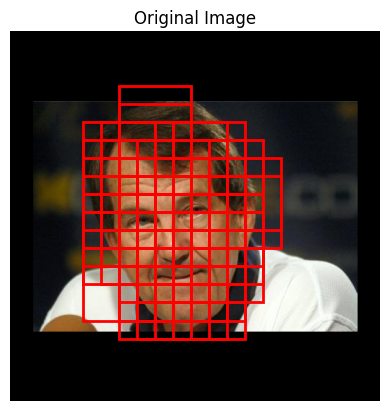

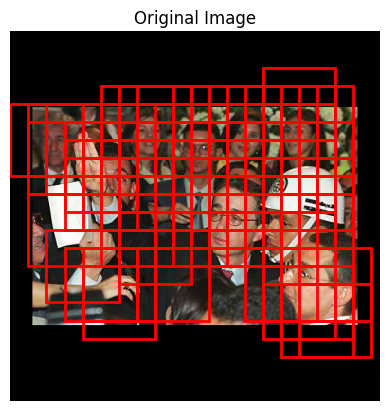

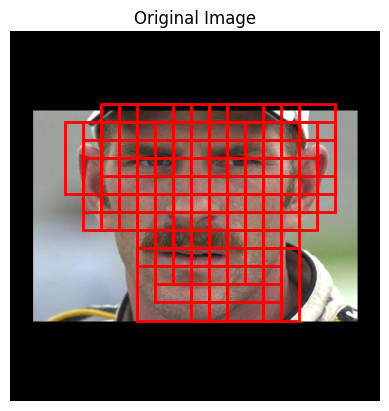

In [14]:
"""
model.eval() 
r = torch.rand(1) * val_size
r = int(r)
for val_samples_batch, val_labels_batch, val_num_faces in val_dataloader:
    break  # Exit the loop after fetching the first batch
img = val_samples_batch[0]
label = val_labels_batch[0]

patches, labels = create_patches(img ,label, val_num_faces[0], val = True)
plt.imshow((img/255.).cpu())
plt.show()

patches = torch.stack(patches, dim=0).to(device)
outputs = torch.argmax(model(patches.permute(0,3,1,2).float()), dim = 1)
for j in range(outputs.shape[0]):
    if (outputs[j] == 1):  # If predicted as face
        plt.imshow((patches[j]/255.).cpu())  # Display the patch
        plt.show()
"""
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from IPython.display import display, clear_output
import time
for i in range(3):
    # Define the patch size and step size
    patch_size = 100  # Patch size is 100x100
    step_size = 25   # Step size is 50 pixels
    
    # Ensure the model is on the same device as the input data
    model.to(device)
    
    model.eval() 
    
    # Get a random sample from the validation dataloader
    for val_samples_batch, val_labels_batch, val_num_faces in val_dataloader:
        break
    
    img = val_samples_batch[i]
    label = val_labels_batch[i]
    
    # Move the input data to the same device as the model
    img = img.to(device)
    label = label.to(device)
    
    # Create patches from the sample and label
    patches, labels, xs, ys = create_patches(img, label, val_num_faces[0], val=True)
    
    # Display the original image
    plt.imshow((img / 255.).cpu())
    plt.title('Original Image')
    plt.axis('off')
    # Iterate over patches and their predictions
    for j, patch in enumerate(patches):
        # Move the patch to the same device as the model
        patch = patch.to(device)
        
        # Predict the label of the patch using the model
        output = torch.argmax(model(patch.unsqueeze(0).permute(0, 3, 1, 2).float()), dim=1)
        
        # If the model predicts the patch as a face, draw a rectangle around it
        if output.item() == 1:
            # Calculate the x-coordinate and y-coordinate of the patch
            """
            x = (j % ((512 - patch_size) // step_size + 1)) * step_size  # Calculate x-coordinate
            y = (j // ((512 - patch_size) // step_size + 1)) * step_size  # Calculate y-coordinate
            """
            w = patch_size
            h = patch_size
            x = xs[j]
            y = ys[j]
            # Create a Rectangle patch
            rect = Rectangle((x, y), w, h, linewidth=2, edgecolor='r', facecolor='none')
            
            # Add the patch to the current axes
            plt.gca().add_patch(rect)
    
    # Show the image with rectangles
    plt.show()

    








In [15]:
import cv2
def detect_faces(rectangles, density_threshold=8):
    """
    Detect faces based on the density of overlapping patches.
    """
    # Calculate the density of overlapping patches in each region
    density_map = np.zeros((512, 512))
    for rectangle in rectangles:
        x1, y1, x2, y2 = rectangle
        density_map[y1:y2, x1:x2] += 1

    # Define a threshold for the density
    thresholded_map_np = density_map > density_threshold
    thresholded_map_tensor = torch.from_numpy(thresholded_map_np)

    contours, _ = cv2.findContours(thresholded_map_tensor.numpy().astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Group the regions above the threshold into clusters
    #labeled_map, num_clusters = connected_components(thresholded_map_tensor)

    # Expand the bounding box of each cluster
    face_rectangles = []
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        face_rectangles.append((x, y, w, h))

    return face_rectangles

In [16]:
def get_face_rectangles(patches, xs, ys, threshold):
    rectangles = []
    for j, patch in enumerate(patches):
        # Move the patch to the same device as the model
        patch = patch.to(device)
        patch_size = 100  # Patch size is 100x100
        
        # Predict the label of the patch using the model
        output = torch.argmax(model(patch.unsqueeze(0).permute(0, 3, 1, 2).float()), dim=1)
        
        # If the model predicts the patch as a face, draw a rectangle around it
        if output.item() == 1:
            # Calculate the x-coordinate and y-coordinate of the patch
            x = xs[j]
            y = ys[j]
            # Create a Rectangle patch
            rect = (x, y, x + patch_size, y + patch_size)
            rectangles.append(rect)

    face_rectangles = detect_faces(rectangles, threshold)
    return face_rectangles


    

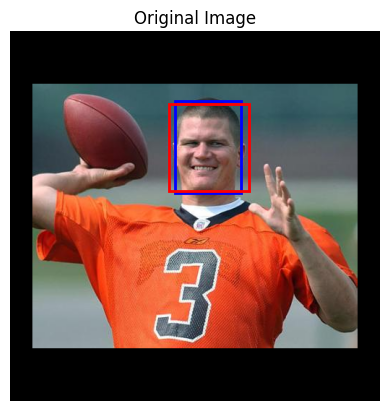

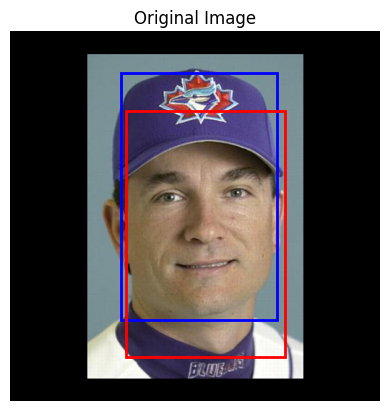

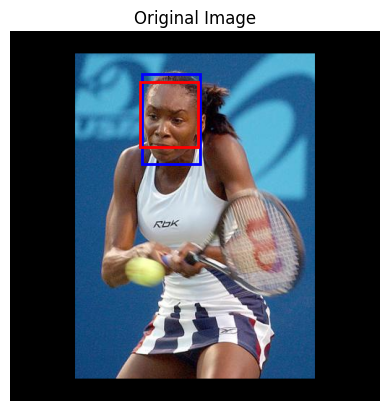

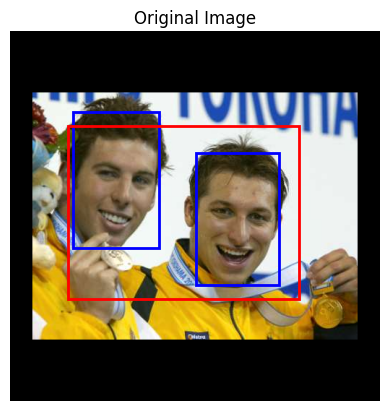

In [17]:
for i in range(4):
    # Define the patch size and step size
    patch_size = 100  # Patch size is 100x100
    step_size = 10   # Step size is 50 pixels
    threshold = 40
    
    # Ensure the model is on the same device as the input data
    model.to(device)
    
    model.eval() 
    
    # Get a random sample from the validation dataloader
    for val_samples_batch, val_labels_batch, val_num_faces in val_dataloader:
        break
    
    img = val_samples_batch[i]
    label = val_labels_batch[i]
    
    # Move the input data to the same device as the model
    img = img.to(device)
    label = label.to(device)
    
    # Create patches from the sample and label
    patches, labels, xs, ys = create_patches(img, label, val_num_faces[0], val=True, step_size = step_size)
    
    # Display the original image
    plt.imshow((img / 255.).cpu())
    for l in label.cpu():
        x, y, w, h, _ = l
        rect = Rectangle((x, y), w, h, linewidth=2, edgecolor='b', facecolor='none')
        plt.gca().add_patch(rect)
    
    plt.title('Original Image')
    plt.axis('off')

    faces = get_face_rectangles(patches, xs, ys, threshold)
    for face in faces:
        x, y, w, h = face
        rect = Rectangle((x, y), w, h, linewidth=2, edgecolor='r', facecolor='none')
            
        # Add the patch to the current axes
        plt.gca().add_patch(rect)
    plt.show()

In [4]:
"""
class HaarCascade(nn.Module):
    def __init__(self):
        super(HaarCascade, self).__init__()
        # Define your layers here
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(128 * 62 * 62, 512)  # Adjusted for input size 3x500x500
        self.fc2 = nn.Linear(512, 4)  # Output 4 values for bounding box coordinates

    def forward(self, x):
        # Define the forward pass
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        # Adjusted for input size 3x500x500
        x = x.reshape(-1, 128 * 62 * 62)  
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Instantiate the model
batch_size = 16  # Set your desired batch size
shuffle = True   # Set whether you want to shuffle the data
num_workers = 4  # Set the number of processes to load data
num_classes = 30
learning_rate = 0.4
num_epochs = 10
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = HaarCascade().to(device)
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Example usage:
train_size = int(0.8 * len(dataset))
#print(len(dataset))
#print(train_size)
val_size = len(dataset) - train_size
#print(val_size)
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=shuffle, num_workers=num_workers)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

for epoch in range(num_epochs):
    model.train()
    lbar = tqdm(train_loader)
    lbar.set_description(f"Epoch {epoch}")
    for batch_idx, (samples_batch, labels_batch, num_faces) in enumerate(lbar):
        samples_batch, labels_batch, num_faces = samples_batch.to(device), labels_batch.to(device), num_faces.to(device)
        labels_batch = labels_batch[:,:, -1]
        optimizer.zero_grad()
        samples_batch = samples_batch.float()
        #print(samples_batch.shape)
        outputs = model(samples_batch.permute(0, 3, 1, 2)).float()
        loss = criterion(outputs, labels_batch)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        if batch_idx % 100 == 99:    # Print every 100 mini-batches
            print('[%d, %5d] loss: %.3f' %
                  (epoch + 1, i + 1, running_loss / 100))
            running_loss = 0.0
"""

  0%|          | 0/128 [00:00<?, ?it/s]

RuntimeError: 0D or 1D target tensor expected, multi-target not supported

In [5]:
"""
class PNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.channels = [3, 10, 16, 32]
        self.down = nn.Sequential(
            nn.Conv2d(self.channels[0], self.channels[1], kernel_size = 3),
            nn.PReLU(self.channels[1]),
            nn.MaxPool2d(kernel_size = 2, stride = 2, ceil_mode = True),
            nn.Conv2d(self.channels[1], self.channels[2], kernel_size = 3),
            nn.PReLU(self.channels[2]),
            nn.Conv2d(self.channels[2], self.channels[3], kernel_size = 3),
            nn.PReLU(self.channels[3])
        )

        #Classification layer
        self.classification = nn.Sequential(
            nn.Conv2d(self.channels[3], 2, kernel_size = 1),
            nn.Softmax(dim = 1)
        )


        #Bounding box regression layer
        self.box = nn.Conv2d(self.channels[3], 4, kernel_size = 1)

    def forward(self, x):
        x = self.down(x)
        classification = self.classification(x)
        bounding_box = self.box(x)

        return classification, bounding_box
"""

In [6]:
"""
class RNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.channels = [3, 28, 48, 64, 128]
        self.down = nn.Sequential(
            nn.Conv2d(self.channels[0], self.channels[1], kernel_size = 3),
            nn.PReLU(self.channels[1]),
            nn.MaxPool2d(kernel_size = 3, stride = 2, ceil_mode = True),
            nn.Conv2d(self.channels[1], self.channels[2], kernel_size = 3),
            nn.PReLU(self.channels[2]),
            nn.MaxPool2d(kernel_size = 3, stride = 2,ceil_mode = True),
            nn.Conv2d(self.channels[2], self.channels[3], kernel_size = 3),
            nn.PReLU(self.channels[3]),
            nn.Flatten(),
            nn.Linear(self.channels[3] * 3 * 3, self.channels[4]),
            nn.PReLU(self.channels[4])
        )

        #Classification layer
        self.classification = nn.Sequential(
            nn.Linear(self.channels[4], 2),
            nn.Softmax(dim = 1)
        )

        #Bounding box regression layer
        self.box = nn.Linear(self.channels[4], 4)
        
    def forward(self, x):
        x = self.down(x)
        classification = self.classification(x)
        bounding_box = self.box(x)

        return classification, bounding_box
"""

In [7]:
"""
class ONet(nn.Module):
    def __init__(self):
        super().__init__()

        self.channels = [3, 32, 64, 64, 128, 256]
        self.down = nn.Sequential(
            nn.Conv2d(self.channels[0], self.channels[1], kernel_size = 3),
            nn.PReLU(self.channels[1]),
            nn.MaxPool2d(kernel_size = 3, stride = 2, ceil_mode = True),
            nn.Conv2d(self.channels[1], self.channels[2], kernel_size = 3),
            nn.PReLU(self.channels[2]),
            nn.MaxPool2d(kernel_size = 3, stride = 2, ceil_mode = True),
            nn.Conv2d(self.channels[2], self.channels[3], kernel_size = 3),
            nn.PReLU(self.channels[3]),
            nn.MaxPool2d(kernel_size = 2, stride = 2, ceil_mode = True),
            nn.Conv2d(self.channels[3], self.channels[4], kernel_size = 2),
            nn.PReLU(self.channels[4]),
            nn.Flatten(),
            nn.Linear(self.channels[4] * 3 * 3, self.channels[5]),
            nn.PReLU(self.channels[5]),
        )

        #Classification layer
        self.classification = nn.Sequential(
            nn.Linear(self.channels[5], 2),
            nn.Softmax(dim = 1)
        )

        #Bounding box regression layer
        self.box = nn.Linear(self.channels[5], 4)
        
    def forward(self, x):
        x = self.down(x)
        classification = self.classification(x)
        bounding_box = self.box(x)

        return classification, bounding_box
"""

In [36]:
"""f
rom torchvision import transforms

def image_pyramid(img, scale_factor = 0.7, min_size =(50, 50)):
    width = int(image.shape[1])
    height = int(img.shape[0])
    imgs = [img]
    while (width > min_size[0] and height > min_size[1]):
        width = int(image.shape[1] * scale_factor)
        height = int(image.shape[0] * scale_factor)
        transform = transforms.Compose([transforms.ToPILImage(), transforms.Resize((height, width)), tranforms.ToTensor()])
        img = transform(img)
        imgs.append(img)
        
    return torch.stack(imgs, dim = 0)
        
"""
    

In [85]:
"""
def sample_patch(img, bbox):
    print(bbox.shape)
    print(len(bbox.tolist()))
    x, y, w, h, _ = bbox[1,1,:].tolist()
    print(image.size())
    ymax, xmax, _ = image.size()

    px = torch.randint(0, xmax - 12, (1,))
    py = torch.randint(0, ymax -12, (1,))
    patch = img[:, py:py + 12, px:px + 12]
    
    overlaps = torch.zeros(2)
    if (px + 12 < x) or (px > x + w) or (py + 12 < y) or (py > y + h):
        overlaps[0] = 1 #no overlap
    else:
        overlaps[1] = 1 #overlap
    
    return patch, overlaps
    """

In [86]:
"""
class PNetTrainer:
    def __init__(self, model, train_loader, val_loader, lr = 0.001):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = model.to(self.device)
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.optimizer = optim.RAdam(self.model.parameters(), lr=lr)
        self.classification_loss = nn.CrossEntropyLoss()
        self.box_loss = nn.MSELoss()
        self.num_patches = 10


    def train(self, epochs):
        for epoch in range(epochs):
            self.model.train()
            lbar = tqdm(self.train_loader)
            lbar.set_description(f"Epoch {epoch}")
            
            train_loss_classification = 0.0
            train_loss_box = 0.0

            for batch_idx, (samples_batch, labels_batch, num_faces) in enumerate(lbar):
                samples_batch, labels_batch, num_faces = samples_batch.to(device), labels_batch.to(device), num_faces.to(device)
                samples_batch = samples_batch.float()
                img_pyramid = image_pyramid(samples_batch)
                for img in img_pyramid:    
                    img = img.permute(0,3,1,2)
                    for p in range(self.num_patches):
                        self.optimizer.zero_grad()
                        patch, overlaps = sample_patch(img, labels_batch)
                        classification_pred, box_pred = self.model(patch)
                        cls_loss = self.classification_loss(classification_pred, overlaps)
                        loss = cls_loss
                        loss.backward()
                        self.optimizer.step()
                        train_loss_classification += cls_loss.item()
                        
    
                    
                    #print(box_pred.shape)
                    #print(labels_batch.shape)
                    #cls_loss = self.classification_loss(classification_pred, labels_batch[:,0])
                    #box_loss = self.box_loss(box_pred, labels_batch[:,1:])
                    #loss = box_loss
    
    
                    
    
                    train_loss_classification += cls_loss.item()
                    #train_loss_box = box_loss.item()

                    train_loss_classification /= len(self.train_loader)
                    #train_loss_box /= len(self.train_loader)

            print(f"Epoch {epoch+1}/{epochs}, "
                  f"Train Loss_cls: {train_loss_cls:.4f}, "
                  f"Train Loss_bbox: {train_loss_bbox:.4f}")


            self.model.eval()
            val_loss_cls = 0.0
            val_loss_bbox = 0.0
            with torch.no_grad():
                for inputs, labels in self.val_loader:
                    inputs, labels = inputs.to(self.device), labels.to(self.device)

                    cls_pred, bbox_pred = self.model(inputs)
                    cls_loss = self.classification_loss(cls_pred, labels[:, 0])
                    bbox_loss = self.bbox_loss(bbox_pred.squeeze(1), labels[:, 1:])

                    val_loss_cls += cls_loss.item()
                    val_loss_bbox += bbox_loss.item()

                val_loss_cls /= len(self.val_loader)
                val_loss_bbox /= len(self.val_loader)

                print(f"Val Loss_cls: {val_loss_cls:.4f}, "
                      f"Val Loss_bbox: {val_loss_bbox:.4f}")
"""

In [87]:
"""
batch_size = 16  # Set your desired batch size
shuffle = True   # Set whether you want to shuffle the data
num_workers = 4  # Set the number of processes to load data
num_classes = 30
learning_rate = 0.4

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = PNet().to(device)

train_size = int(0.8 * len(dataset))
#print(len(dataset))
#print(train_size)
val_size = len(dataset) - train_size
#print(val_size)
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=shuffle, num_workers=num_workers)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
num_epochs = 5

p_trainer = PNetTrainer(model, train_loader, val_loader, learning_rate)

p_trainer.train(num_epochs)
"""

  0%|          | 0/128 [00:00<?, ?it/s]

torch.Size([16, 27, 5])
16
torch.Size([500, 500, 3])


RuntimeError: Given groups=1, weight of size [10, 3, 3, 3], expected input[16, 0, 12, 500] to have 3 channels, but got 0 channels instead